# RSNA Knee Abnormality Detection — CSV EDA

## 分析目标

1. 检查病例、标签和序列表结构。
2. 分析12类标签的阳性率与缺失率。
3. 分析每病例序列数量和扫描协议。
4. 检查人工标注病例与报告病例的差异。
5. 分析报告长度、语言和重复情况。
6. 总结对验证、采样和建模有影响的发现。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

raw_dir = project_root / "data" / "raw"

train = pd.read_csv(raw_dir / "train.csv")
train_series = pd.read_csv(raw_dir / "train_series.csv")
test = pd.read_csv(raw_dir / "test.csv")
test_series = pd.read_csv(raw_dir / "test_series.csv")
sample_submission = pd.read_csv(raw_dir / "sample_submission.csv")

id_col = "StudyInstanceUID"
report_col = "Report"
label_cols = sample_submission.columns.drop(id_col).tolist()

print("训练病例表：", train.shape)
print("训练序列表：", train_series.shape)
print("测试病例表：", test.shape)
print("测试序列表：", test_series.shape)
print("标签数量：", len(label_cols))
print("标签：", label_cols)

训练病例表： (4407, 14)
训练序列表： (24371, 5)
测试病例表： (3, 1)
测试序列表： (15, 5)
标签数量： 12
标签： ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


In [2]:
fully_labeled = train[label_cols].notna().all(axis=1)
fully_missing = train[label_cols].isna().all(axis=1)
partially_labeled = ~(fully_labeled | fully_missing)

checks = {
    "训练病例ID唯一": train[id_col].is_unique,
    "训练序列ID唯一": train_series["SeriesInstanceUID"].is_unique,
    "所有训练病例都有序列": set(train[id_col]) == set(train_series[id_col]),
    "测试病例ID唯一": test[id_col].is_unique,
    "提交病例顺序与test一致": (
        sample_submission[id_col].tolist() == test[id_col].tolist()
    ),
    "提交标签与训练标签一致": (
        sample_submission.columns[1:].tolist() == label_cols
    ),
}

display(pd.Series(checks, name="检查结果"))

print("完整人工标签病例：", fully_labeled.sum())
print("全部标签缺失病例：", fully_missing.sum())
print("部分标签缺失病例：", partially_labeled.sum())

assert all(checks.values())
assert partially_labeled.sum() == 0

训练病例ID唯一         True
训练序列ID唯一         True
所有训练病例都有序列       True
测试病例ID唯一         True
提交病例顺序与test一致    True
提交标签与训练标签一致      True
Name: 检查结果, dtype: bool

完整人工标签病例： 58
全部标签缺失病例： 4349
部分标签缺失病例： 0


### 初步结论

训练集包含4,407个病例，但只有58个病例具有完整的12类人工标签，其余4,349个病例只有报告文本，没有人工标签。标签缺失是病例级、成组发生的，而不是单个标签随机缺失。因此不能把缺失标签填成0。后续应分别处理人工标注病例和报告弱监督病例，并在模型训练中保留标签 mask。

In [3]:
label_summary = pd.DataFrame({
    "有效标签数": train[label_cols].notna().sum(),
    "阳性数": train[label_cols].sum(),
    "阴性数": train[label_cols].eq(0).sum(),
    "缺失数": train[label_cols].isna().sum(),
})

label_summary["阳性率"] = (
    label_summary["阳性数"] / label_summary["有效标签数"]
)

label_summary["缺失率"] = (
    label_summary["缺失数"] / len(train)
)

label_summary["阳性数"] = label_summary["阳性数"].astype(int)

label_summary = label_summary.sort_values(
    "阳性率",
    ascending=False,
)

display(
    label_summary.style.format({
        "阳性率": "{:.1%}",
        "缺失率": "{:.1%}",
    })
)

,有效标签数,阳性数,阴性数,缺失数,阳性率,缺失率
Effusion,58,35,23,4349,60.3%,98.7%
Synovitis,58,27,31,4349,46.6%,98.7%
Medial Meniscus,58,26,32,4349,44.8%,98.7%
ACL,58,24,34,4349,41.4%,98.7%
Lateral Meniscus,58,23,35,4349,39.7%,98.7%
PF OA,58,21,37,4349,36.2%,98.7%
Contusion,58,19,39,4349,32.8%,98.7%
Fracture,58,18,40,4349,31.0%,98.7%
Medial OA,58,15,43,4349,25.9%,98.7%
Baker's,58,12,46,4349,20.7%,98.7%


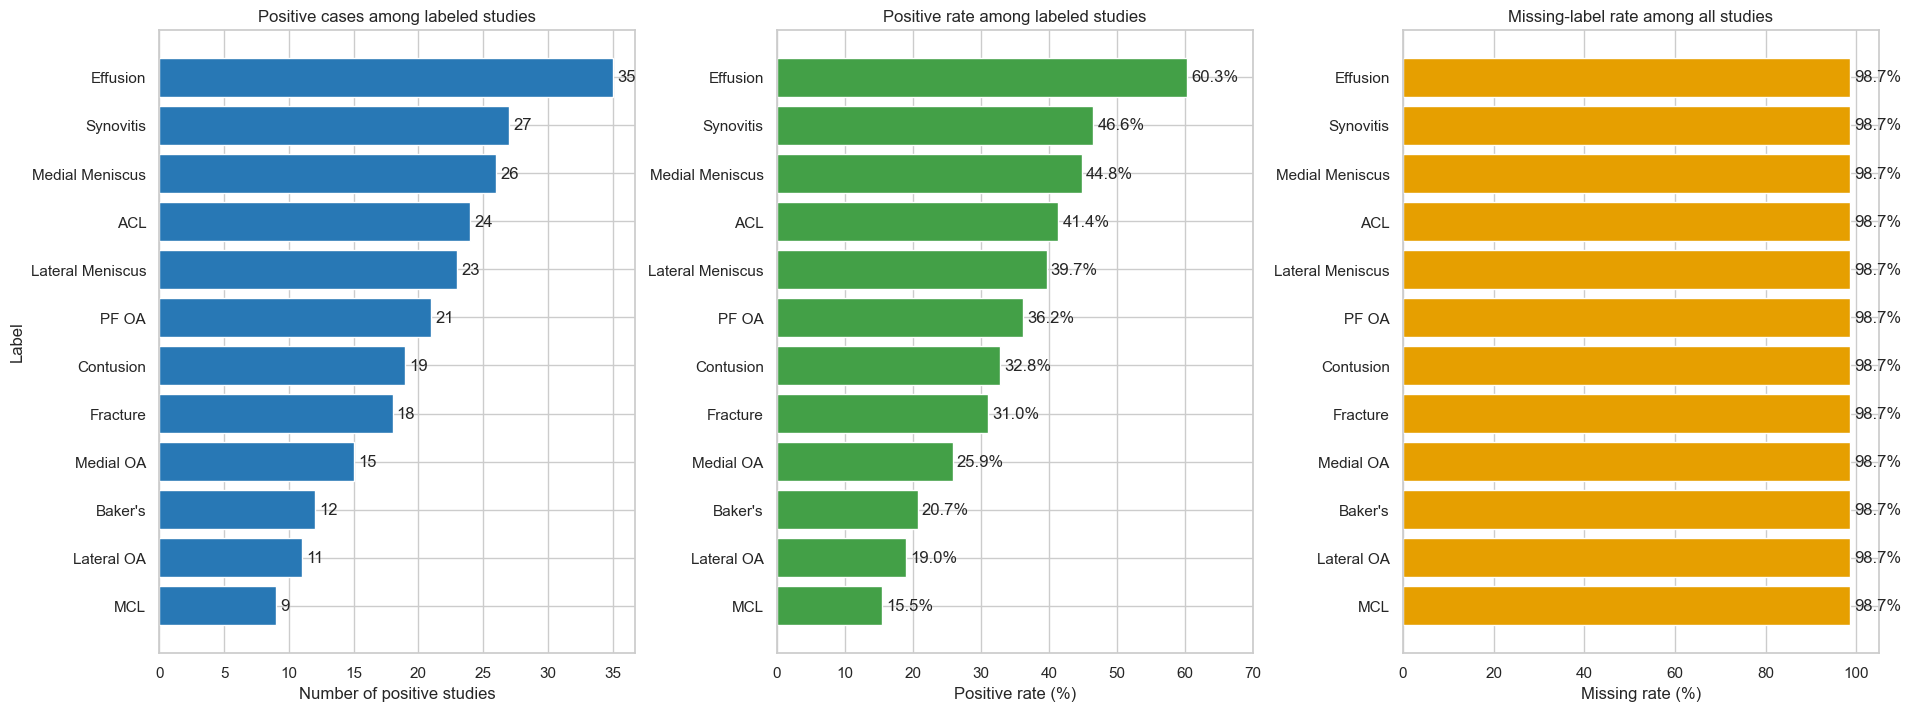

In [4]:
plot_data = label_summary.sort_values("阳性率", ascending=True)

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(19, 7),
    constrained_layout=True,
)

# 阳性病例数
bars = axes[0].barh(
    plot_data.index,
    plot_data["阳性数"],
    color="#2878B5",
)
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Positive cases among labeled studies")
axes[0].set_xlabel("Number of positive studies")
axes[0].set_ylabel("Label")

# 人工标签病例中的阳性率
bars = axes[1].barh(
    plot_data.index,
    plot_data["阳性率"] * 100,
    color="#43A047",
)
axes[1].bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in plot_data["阳性率"] * 100],
    padding=3,
)
axes[1].set_title("Positive rate among labeled studies")
axes[1].set_xlabel("Positive rate (%)")
axes[1].set_xlim(0, 70)
axes[1].set_ylabel("")

# 全部训练病例中的标签缺失率
bars = axes[2].barh(
    plot_data.index,
    plot_data["缺失率"] * 100,
    color="#E69F00",
)
axes[2].bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in plot_data["缺失率"] * 100],
    padding=3,
)
axes[2].set_title("Missing-label rate among all studies")
axes[2].set_xlabel("Missing rate (%)")
axes[2].set_xlim(0, 105)
axes[2].set_ylabel("")

plt.show()

### 标签分布结论

1. 4,407个训练病例中只有58个病例具有人工标签，标签缺失率达到98.68%。缺失发生在病例级：一个病例要么拥有全部12类标签，要么全部缺失。

2. 人工标注病例中存在明显的类别不平衡。Effusion阳性率最高，为60.3%；MCL阳性率最低，为15.5%，仅有9个阳性病例。

3. 标签缺失不能填充为0。未标注病例不能直接作为12类阴性病例参与监督训练，后续必须使用标签mask，或从报告中构造经过质量验证的弱标签。

4. 只有58个人工标注病例，任何单次训练集—验证集随机划分都会非常不稳定。尤其MCL只有9个阳性病例，后续必须采用固定的病例级多标签分层交叉验证，并检查每折每类阳性数。

5. 阳性率是基于58个人工标注病例计算的，不能解释为全部4,407个训练病例中的真实患病率，因为人工标注病例可能并非随机抽样。

## 病例与MRI序列分布

本节分析每个病例包含多少个MRI序列，以及Sagittal、Coronal和Axial三个解剖平面的覆盖情况。

In [6]:
series_per_study = (
    train_series
    .groupby(id_col)
    .agg(
        序列数=("SeriesInstanceUID", "nunique"),
    )
    .reset_index()
)

display(series_per_study["序列数"].describe())

assert len(series_per_study) == len(train)
assert series_per_study[id_col].is_unique

count    4407.000000
mean        5.530066
std         1.393826
min         3.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        14.000000
Name: 序列数, dtype: float64

### 平均值的意义
它表示平均每个研究（Study）包含多少个图像序列（Series）。

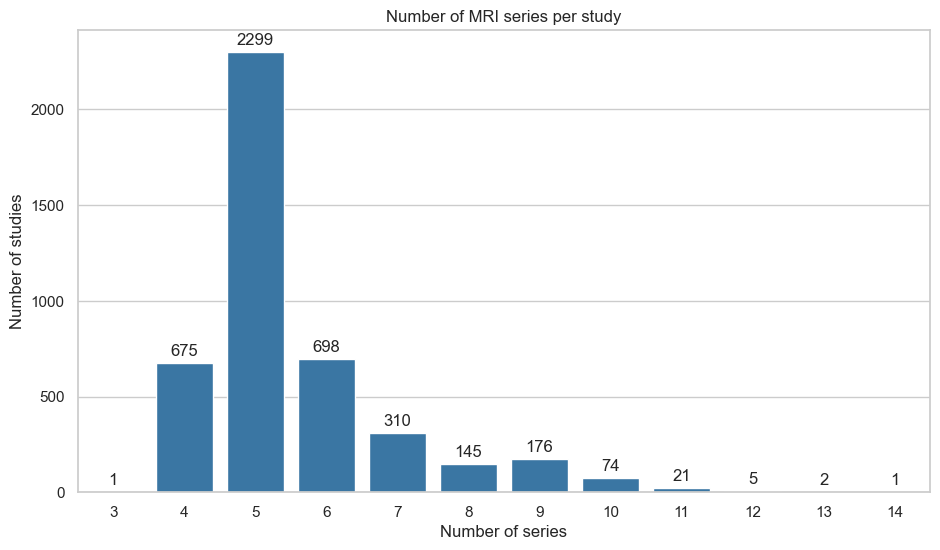

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.countplot(
    data=series_per_study,
    x="序列数",
    color="#2878B5",
    ax=ax,
)

ax.bar_label(ax.containers[0], padding=3)
ax.set_title("Number of MRI series per study")
ax.set_xlabel("Number of series")
ax.set_ylabel("Number of studies")

plt.show()

In [8]:
plane_order = ["Sagittal", "Coronal", "Axial"]

plane_by_study = pd.crosstab(
    train_series[id_col],
    train_series["Anatomical_Plane"],
).reindex(columns=plane_order, fill_value=0)

plane_presence = plane_by_study.gt(0)

plane_summary = pd.DataFrame({
    "序列数": (
        train_series["Anatomical_Plane"]
        .value_counts()
        .reindex(plane_order)
    ),
    "覆盖病例数": plane_presence.sum().reindex(plane_order),
    "覆盖率": plane_presence.mean().reindex(plane_order),
})

display(
    plane_summary.style.format({
        "覆盖率": "{:.2%}",
    })
)

assert plane_presence.all(axis=1).all()

,序列数,覆盖病例数,覆盖率
Anatomical_Plane,,,
Sagittal,9864,4407,100.00%
Coronal,8609,4407,100.00%
Axial,5898,4407,100.00%


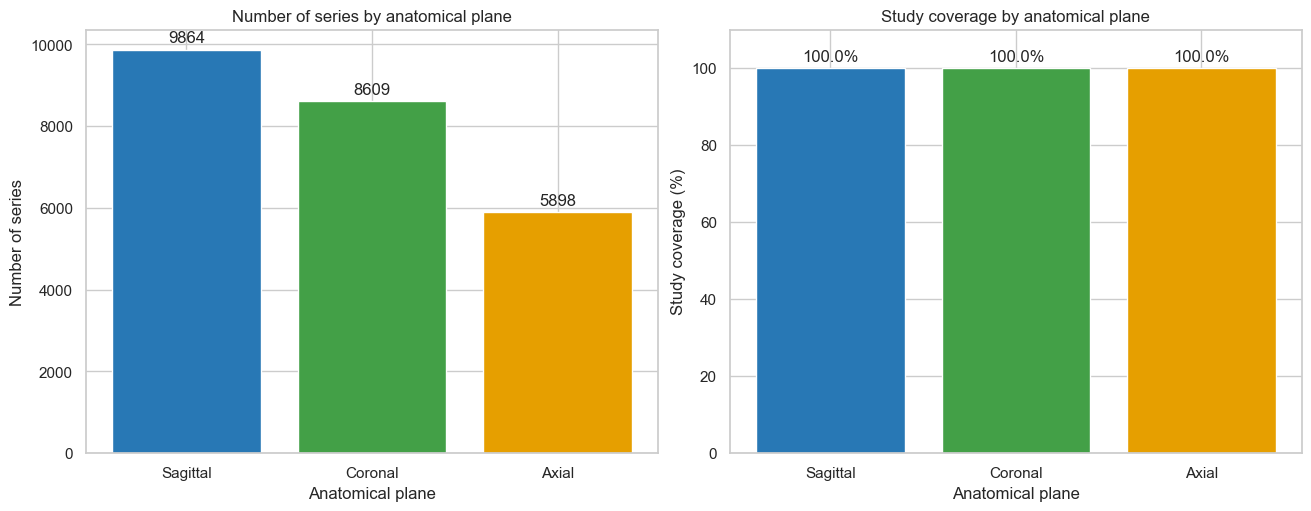

In [9]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5),
    constrained_layout=True,
)

bars = axes[0].bar(
    plane_summary.index,
    plane_summary["序列数"],
    color=["#2878B5", "#43A047", "#E69F00"],
)
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Number of series by anatomical plane")
axes[0].set_xlabel("Anatomical plane")
axes[0].set_ylabel("Number of series")

bars = axes[1].bar(
    plane_summary.index,
    plane_summary["覆盖率"] * 100,
    color=["#2878B5", "#43A047", "#E69F00"],
)
axes[1].bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in plane_summary["覆盖率"] * 100],
    padding=3,
)
axes[1].set_title("Study coverage by anatomical plane")
axes[1].set_xlabel("Anatomical plane")
axes[1].set_ylabel("Study coverage (%)")
axes[1].set_ylim(0, 110)

plt.show()

### 病例与序列分布结论

1. 每个病例包含3–14个MRI序列，中位数为5个，说明病例之间的序列数量并不固定。后续模型需要采用序列采样、池化或病例级聚合，而不能依赖固定序列数。

2. 每病例5个序列最常见，共2,299例。大多数病例包含4–6个序列，少数病例拥有10个以上序列，应在DICOM阶段检查这些极端病例是否包含重复序列或特殊扫描协议。

3. 所有4,407个训练病例都同时覆盖Sagittal、Coronal和Axial三个解剖平面，因此后续可以比较单平面模型，并研究三平面融合。

4. Sagittal序列总数最多，Axial序列总数最少，但三个平面的病例覆盖率都是100%。序列总数不同不代表病例覆盖率不同，而是每个病例在不同平面上拥有的序列数量不同。